## Cobb County Property Sales Data for January 2024
---
**Data Cleaning and Initial EDA**

In [2]:
# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Datetime handling
from datetime import datetime as dt

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

# Plot styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

---
**Read in Dataset**

In [4]:
file_path = '../01-dataSets/01-sales/Jan24-CobbCountyGA-20260418-7cc55305db214785ab51bb8c78c21dcc.csv'

In [5]:
jan2024 = pd.read_csv(file_path)

---
**Basic Info about Data**

In [7]:
# rows and columns
jan2024.shape

(1465, 18)

In [8]:
# first five rows
jan2024.head()

,Parcel ID,Street Name,Owner Name,Owner Address,Grantor,Grantee,Sale Date,Sale Price,Sales Validity,Acres,Tax District,Square Ft,Neighborhood,Zoning,Districts,Landlots,Foundation,School District
0,19004500540,2364 ELLIS MOUNTAIN DR SW,KENNETH GEORGE BEREZINSKI REVOCABLE TRUS | C/O...,KENNETH GEORGE BEREZINSKI REVOCABLE TRUS | C/O...,CND ELLIS LLC,WEEKLEY HOMES LLC,1/31/2024,"$1,463,000.00",NaN,0.67,(9) UNINCORPORATED,3201,ELLIS - 19034527,NaN,19,45,1 - NONE,Hillgrove High - 520
1,17041600350,768 TIMBERLAND ST,EVERHART CLAYTON & PLATT KIMBERLY,EVERHART CLAYTON & PLATT KIMBERLY | 768 TIMBE...,CHAPMAN ERIC & CAPPARELLI TANIA,HABERSTROH BRADLEY & AMANDA,1/31/2024,"$475,000.00",VALID SALE,0.23,(6) SMYRNA,1125,CHENEY WOODS - 06170072,NaN,17,416,4 - FULL,Campbell High - 517
2,20030200460,492 TEAGUE DR,DUPLANTIS ZACHARY NATHANIEL,DUPLANTIS ZACHARY NATHANIEL | 492 TEAGUE DR N...,ONLINE ABSTRACTING LLC,AJS AUCTIONS LLC,1/8/2024,"$170,000.00",VALID SALE,0.00,(9) UNINCORPORATED,1480,RED ROCK HILLS - 20051497,NaN,20,302,4 - FULL,Harrison High - 516
3,17070100420,2018 NANCY CIR,NICOLAUS CHRISTOPHER & THOMAS SUMMER,NICOLAUS CHRISTOPHER & THOMAS SUMMER | 2018 N...,HARTSELL ANN WILSON,CMNC HOMES LLC,1/16/2024,"$225,000.00",NaN,0.00,(6) SMYRNA,1845,ARGYLE ESTATES I - 17072820,NaN,17,701,2 - CRAWL,Campbell High - 517
4,20018701940,5327 CAMDEN LAKE DR,LILA DILCIA M,LILA DILCIA M | 5327 CAMDEN LAKE DR NW | ACWO...,LILA DILCIA MARIA,LILA BIANCA M,1/4/2024,$0.00,NaN,0.00,(9) UNINCORPORATED,2967,CAMDEN POINTE - 20062972,NaN,20,187,4 - FULL,Allatoona High - 521


In [9]:
# last five rows
jan2024.tail()

,Parcel ID,Street Name,Owner Name,Owner Address,Grantor,Grantee,Sale Date,Sale Price,Sales Validity,Acres,Tax District,Square Ft,Neighborhood,Zoning,Districts,Landlots,Foundation,School District
1460,16121601120,99 LAKE ST,DRABIK KIMBERLY ANNETTE,DRABIK KIMBERLY ANNETTE | 3304 GEORGETOWN PL ...,99 LAKE STREET LLC,DRABIK KIMBERLY ANNETTE,1/2/2024,"$370,000.00",VALID SALE,0.00,(4) MARIETTA,988,CITY OF MARIETTA - 04034015,NaN,16,1216,2 - CRAWL,Marietta High - 999
1461,16029600120,210 SUBURBAN DR,TOZZO RENALDO & GOULART CARLOS A,TOZZO RENALDO & GOULART CARLOS A | 210 SUBURB...,HICKS CLIFFORD BLAKE,TOZZO RENALDO & GOULART CARLOS A,1/2/2024,"$310,000.00",VALID SALE,0.00,(9) UNINCORPORATED,1515,DURHAM ESTATES - 16121176,NaN,16,296,3 - PART,Sprayberry High - 510
1462,16027100200,1782 JODY DR,MIS LLC,MIS LLC | 1095 OLD ROSWELL RD | ROSWELL GA 30076,SAYAG YIZHAQ,MIS LLC,1/1/2024,$0.00,NaN,0.00,(9) UNINCORPORATED,1480,SHALLOWFORD OAKS - 16111742,NaN,16,271,1 - NONE,Kell High - 519
1463,19067600280,4956 SHIPP RD,CENTENO LUIS A & | VAZQUEZ GUADALUPE ALEJANDRA...,CENTENO LUIS A & | VAZQUEZ GUADALUPE ALEJANDRA...,GOUCIDE YACINTHE & SILVIA,CENTENO LUIS A &,1/1/2024,$0.00,NaN,0.00,(5) POWDER SPRINGS,1663,COUNTRY COVE - 19052629,NaN,19,676,4 - FULL,McEachern High - 501
1464,16042700790,120 CHASTAIN RD UNIT 604,SOUTHERN MAGNOLIA ENDEAVORS LLC,SOUTHERN MAGNOLIA ENDEAVORS LLC | 3460 PRESTO...,THOMPSON THOMAS B,SOUTHERN MAGNOLIA ENDEAVORS LLC,1/1/2024,$10.00,NaN,0.00,(9) UNINCORPORATED,1614,BROOKHAVEN OF EAST COBB - CONDOS - 20019540,NaN,16,427,1 - NONE,Kell High - 519


---
**Information about Columns: format to correct data types, check null values, standardize names**

In [11]:
# initial column data types
jan2024.dtypes

Parcel ID            int64
Street Name         object
Owner Name          object
Owner Address       object
Grantor             object
Grantee             object
Sale Date           object
Sale Price          object
Sales Validity      object
Acres              float64
Tax District        object
Square Ft            int64
Neighborhood        object
Zoning              object
Districts            int64
Landlots             int64
Foundation          object
School District     object
dtype: object

In [12]:
# snake_case column names
jan2024.columns = jan2024.columns.str.lower()
jan2024.columns = jan2024.columns.str.strip().str.replace(' ', '_')

# display formatted/standardized column names
jan2024.columns

Index(['parcel_id', 'street_name', 'owner_name', 'owner_address', 'grantor',
       'grantee', 'sale_date', 'sale_price', 'sales_validity', 'acres',
       'tax_district', 'square_ft', 'neighborhood', 'zoning', 'districts',
       'landlots', 'foundation', 'school_district'],
      dtype='object')

In [13]:
# parcel IDs should be strings
jan2024['parcel_id'] = jan2024['parcel_id'].astype(str)

# confirm
jan2024.dtypes[:3]

parcel_id      object
street_name    object
owner_name     object
dtype: object

In [14]:
# convert sale_date to datetime object
jan2024['sale_date'] = pd.to_datetime(jan2024['sale_date'], errors='coerce')

# confirm
jan2024.dtypes[5:8]

grantee               object
sale_date     datetime64[ns]
sale_price            object
dtype: object

In [15]:
# remove $ sign from sale_price and convert to float

jan2024['sale_price'] = pd.to_numeric(
    jan2024['sale_price'].str.replace('$',"", regex = False).str.replace(",","", regex=False),
    errors='coerce')

# confirm
jan2024.dtypes[5:8]

grantee               object
sale_date     datetime64[ns]
sale_price           float64
dtype: object

In [16]:
# convert districts and landlots columns to strings
jan2024[['districts', 'landlots']] = jan2024[['districts', 'landlots']].astype(str)

# confirm
jan2024.dtypes[13:]

zoning             object
districts          object
landlots           object
foundation         object
school_district    object
dtype: object

In [17]:
# verify all columns at once
jan2024.dtypes

parcel_id                  object
street_name                object
owner_name                 object
owner_address              object
grantor                    object
grantee                    object
sale_date          datetime64[ns]
sale_price                float64
sales_validity             object
acres                     float64
tax_district               object
square_ft                   int64
neighborhood               object
zoning                     object
districts                  object
landlots                   object
foundation                 object
school_district            object
dtype: object

In [18]:
# second confirmation by taking a look at the first two rows
jan2024.head(2)

,parcel_id,street_name,owner_name,owner_address,grantor,grantee,sale_date,sale_price,sales_validity,acres,tax_district,square_ft,neighborhood,zoning,districts,landlots,foundation,school_district
0,19004500540,2364 ELLIS MOUNTAIN DR SW,KENNETH GEORGE BEREZINSKI REVOCABLE TRUS | C/O...,KENNETH GEORGE BEREZINSKI REVOCABLE TRUS | C/O...,CND ELLIS LLC,WEEKLEY HOMES LLC,2024-01-31,1463000.00,NaN,0.67,(9) UNINCORPORATED,3201,ELLIS - 19034527,NaN,19,45,1 - NONE,Hillgrove High - 520
1,17041600350,768 TIMBERLAND ST,EVERHART CLAYTON & PLATT KIMBERLY,EVERHART CLAYTON & PLATT KIMBERLY | 768 TIMBE...,CHAPMAN ERIC & CAPPARELLI TANIA,HABERSTROH BRADLEY & AMANDA,2024-01-31,475000.00,VALID SALE,0.23,(6) SMYRNA,1125,CHENEY WOODS - 06170072,NaN,17,416,4 - FULL,Campbell High - 517


In [19]:
# check null values
jan2024.isnull().sum()

parcel_id             0
street_name           0
owner_name            0
owner_address         0
grantor               0
grantee               0
sale_date             0
sale_price            0
sales_validity      916
acres                 0
tax_district          0
square_ft             0
neighborhood          0
zoning             1318
districts             0
landlots              0
foundation           87
school_district      33
dtype: int64

In [20]:
# check unique values for sales_validity
jan2024['sales_validity'].unique()

array([nan, 'VALID SALE'], dtype=object)

There's already 916 rows with nulls (nan).  Run value counts to confirm 'VALID SALE' accounts for the remainder of rows.
It should be.

In [22]:
jan2024['sales_validity'].value_counts()

sales_validity
VALID SALE    549
Name: count, dtype: int64

Column 'sales_validity' has 916 nulls/missing values. Add the 549 rows where the value is 'VALID SALE' and the total
equals 1,465.  That's the total number of rows.
Per independent research, there's a concept in Real Estate called "Arm's Length Sale".  These are sales where the seller and buyer are completely independent of each other.  There is no professional or personal relationship between the two parties.  Therefore, the final price is subject to true market conditions and not factors that my distort the true value of the property.  Some of those factors may be divorce, foreclosure, discounted sale from parent to child, etc.
Based on that knowledge, and in order to build a robust AVM tool, the professional recommendation is to drop all the rows where 'sale_validity' is null.  Just keep the rows where the entry is 'VALID SALE'.  These are true market values.
That said, we'll keep the nulls on a separate dataset for further research outside the main AVM tool

In [24]:
# filter out the NULL values and store separately
null_sales = jan2024[jan2024['sales_validity'].isna()]

# number of rows should be 916
null_sales.shape

(916, 18)

In [25]:
# take a look at the first lines
null_sales.head()

,parcel_id,street_name,owner_name,owner_address,grantor,grantee,sale_date,sale_price,sales_validity,acres,tax_district,square_ft,neighborhood,zoning,districts,landlots,foundation,school_district
0,19004500540,2364 ELLIS MOUNTAIN DR SW,KENNETH GEORGE BEREZINSKI REVOCABLE TRUS | C/O...,KENNETH GEORGE BEREZINSKI REVOCABLE TRUS | C/O...,CND ELLIS LLC,WEEKLEY HOMES LLC,2024-01-31,1463000.00,NaN,0.67,(9) UNINCORPORATED,3201,ELLIS - 19034527,NaN,19,45,1 - NONE,Hillgrove High - 520
3,17070100420,2018 NANCY CIR,NICOLAUS CHRISTOPHER & THOMAS SUMMER,NICOLAUS CHRISTOPHER & THOMAS SUMMER | 2018 N...,HARTSELL ANN WILSON,CMNC HOMES LLC,2024-01-16,225000.00,NaN,0.00,(6) SMYRNA,1845,ARGYLE ESTATES I - 17072820,NaN,17,701,2 - CRAWL,Campbell High - 517
4,20018701940,5327 CAMDEN LAKE DR,LILA DILCIA M,LILA DILCIA M | 5327 CAMDEN LAKE DR NW | ACWO...,LILA DILCIA MARIA,LILA BIANCA M,2024-01-04,0.00,NaN,0.00,(9) UNINCORPORATED,2967,CAMDEN POINTE - 20062972,NaN,20,187,4 - FULL,Allatoona High - 521
5,20018400040,4420 OLD STILESBORO RD,FAIRHOM INVESTMENTS LLC,FAIRHOM INVESTMENTS LLC | 7362 MEADOW GRASS A...,TABE OBIT-TABOT & MARGARET,CAELLUM QUEST REAL ESTATE HOLDINGS LLC,2024-01-26,320000.00,NaN,2.42,(9) UNINCORPORATED,1638,HOMESITE - 20049991,NaN,20,184,4 - FULL,Allatoona High - 521
6,17018300560,45 DRISKELL AVE,BAH MAIMOUNA,BAH MAIMOUNA | 94 RANDOLPH ST NE | ATLANTA GA...,MOORE SHEILA,MOORE SHEILA,2024-01-15,0.00,NaN,0.00,(M) MABLETON,1662,DRISKELL I - M0000282,NaN,17,183,2 - CRAWL,Pebblebrook High - 506


In [26]:
# confirm all 916 rows show NULL under 'sales_validity'
null_sales.isnull().sum()

parcel_id            0
street_name          0
owner_name           0
owner_address        0
grantor              0
grantee              0
sale_date            0
sale_price           0
sales_validity     916
acres                0
tax_district         0
square_ft            0
neighborhood         0
zoning             838
districts            0
landlots             0
foundation          67
school_district     21
dtype: int64

In [27]:
# save this data separately in its own CSV file
save_to_path = '../01-dataSets/01-sales/non_valid_sales/Jan24_Nulls.csv'
null_sales.to_csv(save_to_path, index = False)

Now it's time to sever these rows from the main dataset to continue with the data cleaning exercise.

In [29]:
print(f'Before: {jan2024.shape[0]}')
jan2024 = jan2024[jan2024['sales_validity'].notna()]
print(f'After: {jan2024.shape[0]}')

Before: 1465
After: 549


In [30]:
# check all columns again
jan2024.isnull().sum()

parcel_id            0
street_name          0
owner_name           0
owner_address        0
grantor              0
grantee              0
sale_date            0
sale_price           0
sales_validity       0
acres                0
tax_district         0
square_ft            0
neighborhood         0
zoning             480
districts            0
landlots             0
foundation          20
school_district     12
dtype: int64

---
**Review Columns Unique Values and Counts**

Turn this into a function to avoid DRY: pass in the column names directly from DF

**Column**: `parcel_id`

In [32]:
# unique values and count for parcel_id
jan2024['parcel_id'].value_counts()

parcel_id
17041600350    1
17014700330    1
20012101310    1
17026600120    1
19079400840    1
              ..
17026900450    1
16085900050    1
19083300790    1
19072600530    1
16029600120    1
Name: count, Length: 549, dtype: int64

All unique values, as it should be.

**Column**: `street_name`

In [34]:
# unique values and count for street_name
jan2024['street_name'].value_counts()

street_name
768 TIMBERLAND ST      1
270 HEATHERSETT DR     1
4531 PEPPERMILL PL     1
183 OAK KNOLL CT       1
3501 HOPKINS CT        1
                      ..
294 WOODVIEW LN        1
1579 BELLS FERRY RD    1
3919 SHELLEYDALE DR    1
603 NEW HORIZON ST     1
210 SUBURBAN DR        1
Name: count, Length: 549, dtype: int64

All unique values, as it should be.  One unique address to one unique parcel ID.

**Column**: `owner_name`

In [36]:
# unique values and count for owner_name
jan2024['owner_name'].value_counts()

owner_name
KAWASAKI ICHIRO                                              2
SAWAYAMA HIROYUKI                                            2
TALLCOTT HOME RENOVATIONS LLC                                2
EVERHART CLAYTON & PLATT KIMBERLY                            1
MATTLE KARL & VICKI                                          1
                                                            ..
OLEWNIK MICHAEL N & ASHLEY                                   1
NGUYEN HOANG PHU MINH & THUY DUNG NGOC                       1
FORTSON THOMAS                                               1
WILMS ULRICH H  & WILMS HANS TREVOR & | WILMS TROY DIETER    1
TOZZO RENALDO & GOULART CARLOS A                             1
Name: count, Length: 546, dtype: int64

There are just three owners with duplicates.  One would assume that perhaps these three owners closed on two different properties within the same month - specially given the fact that we already confirmed all parcel IDs and addresses are unique.  However, let's dispel that assumption by check those specific rows.

In [38]:
jan2024[jan2024['owner_name'].duplicated(keep = False)]

,parcel_id,street_name,owner_name,owner_address,grantor,grantee,sale_date,sale_price,sales_validity,acres,tax_district,square_ft,neighborhood,zoning,districts,landlots,foundation,school_district
562,16014500390,749 MAGGIE CT,SAWAYAMA HIROYUKI,SAWAYAMA HIROYUKI | 5050 QUORUM DR | DALLAS T...,OPEN HOUSE ATLANTA REALTY & INVESTMENTS,SAWAYAMA HIROYUKI,2024-01-30,541000.00,VALID SALE,0.00,(9) UNINCORPORATED,2170,EDGEWATER EAST - 20012243,NaN,16,145,4 - FULL,Kell High - 519
570,20001502980,5113 OAK BRANCH LN,SAWAYAMA HIROYUKI,SAWAYAMA HIROYUKI | 5050 QUORUM DR | DALLAS T...,OPEN HOUSE ATLANTA REALTY & INVESTMENTS,SAWAYAMA HIROYUKI,2024-01-30,495000.00,VALID SALE,0.00,(9) UNINCORPORATED,2961,OAK POINTE - 20012904,NaN,20,15,4 - FULL,North Cobb High - 505
575,16006700630,4759 SHALLOW RIDGE RD,KAWASAKI ICHIRO,KAWASAKI ICHIRO | 5050 QUORUM DR | DALLAS TX ...,OPEN HOUSE ATLANTA REALTY & INVESTMENTS,KAWASAKI ICHIRO,2024-01-30,425000.00,VALID SALE,0.00,(9) UNINCORPORATED,1962,FALCON HILLS - 16122387,NaN,16,67,4 - FULL,Kell High - 519
576,19097400150,4730 SPRING GATE DR,KAWASAKI ICHIRO,KAWASAKI ICHIRO | 5050 QUORUM DR | DALLAS TX ...,OPEN HOUSE ATLANTA REALTY & INVESTMENTS,KAWASAKI ICHIRO,2024-01-30,376000.00,VALID SALE,0.00,(5) POWDER SPRINGS,1398,SPRING GATE - 19042404,NaN,19,974,4 - FULL,McEachern High - 501
668,17015101190,369 BLACK OAK CT,TALLCOTT HOME RENOVATIONS LLC,TALLCOTT HOME RENOVATIONS LLC | 96 BROWN AVE ...,BOTELER MICHAEL D,TALLCOTT HOME RENOVATIONS LLC,2024-01-26,197500.00,VALID SALE,0.00,(4) MARIETTA,1024,PLESANT OAKS TH'S - 04029117,NaN,17,151,2 - CRAWL,Marietta High - 999
730,16128200110,1241 KASANDRA DR,TALLCOTT HOME RENOVATIONS LLC,TALLCOTT HOME RENOVATIONS LLC | 96 BROWN AVE ...,FAGEN-BENNETT FRAN R,TALLCOTT HOME RENOVATIONS LLC,2024-01-25,249300.00,VALID SALE,0.00,(4) MARIETTA,936,MCLAIN G W ESTATE - 04030033,NaN,16,1282,2 - CRAWL,Marietta High - 999


All six sales look legit.

**Column**: `owner_address`

In [40]:
# unique values and count for owner_address
# should follow same pattern as 'owner_name'
jan2024['owner_address'].value_counts()

owner_address
KAWASAKI ICHIRO | 5050  QUORUM DR | DALLAS TX 75254                                                        2
SAWAYAMA HIROYUKI | 5050  QUORUM DR | DALLAS TX 75254                                                      2
TALLCOTT HOME RENOVATIONS LLC | 96  BROWN AVE NW | MARIETTA GA 30064                                       2
EVERHART CLAYTON & PLATT KIMBERLY | 768  TIMBERLAND ST SE | SMYRNA GA 30080                                1
MATTLE KARL & VICKI | 1470  MILFORD CT N | MARIETTA GA 30008                                               1
                                                                                                          ..
OLEWNIK MICHAEL N & ASHLEY | 3456  PLANTATION RDG NW | ACWORTH GA 30101                                    1
NGUYEN HOANG PHU MINH & THUY DUNG NGOC | 2132  SOFT PINE LN NW | ACWORTH GA 30102                          1
FORTSON THOMAS | 294  WOODVIEW LN SE | SMYRNA GA 30082                                                     1
WILMS

**Column**: `grantor`

In [175]:
# unique values and count for grantor
jan2024['grantor'].value_counts()

grantor
OPENDOOR PROPERTY TRUST I                  15
TRATON LLC                                 12
OPEN HOUSE ATLANTA REALTY & INVESTMENTS     8
KERLEY FAMILY HOMES LLC                     7
DR HORTON INC                               6
                                           ..
RALPH DAVID J  &  LYNN M                    1
CHENG KELLY                                 1
CRABTREE THEODORE J                         1
DANIELS LATONYA                             1
HICKS CLIFFORD BLAKE                        1
Name: count, Length: 474, dtype: int64

Conventional wisdom would lead one to think that a grantor (seller) would only transact a property once every several years since these are very large and rather complex purchases.  So, any grantor with two or more transactions within a single month is very likely an investor or company.  Let's find out.

In [255]:
# first, how many grantors transacted two or more properties in Jan 2024?
duplicate_grantor_mask = jan2024['grantor'].duplicated(keep=False)

print('Unique grantors with multiple transactions:', jan2024.loc[duplicate_grantor_mask, 'grantor'].nunique())
print('Total rows for those grantors:', duplicate_grantor_mask.sum())

Unique grantors with multiple transactions: 24
Total rows for those grantors: 99


In [290]:
# view their names
jan2024.loc[duplicate_grantor_mask, 'grantor'].unique()

array(['MERITAGE HOMES OF GEORGIA INC', 'OHC WIGLEY LLC',
       'ASHTON ATLANTA RESIDENTIAL LLC', 'D&Y ASSOCIATES LLC',
       'KERLEY FAMILY HOMES LLC', 'TRATON LLC', 'WEEKLEY HOMES LLC',
       'PARAN HOMES LLC', 'OPENDOOR PROPERTY TRUST I', 'JWC ACWORTH LLC',
       'D R HORTON INC', 'DAVIDSON HOMES LLC',
       'SFR INVESTMENTS V BORROWER TRS 1 LLC', 'SYNERGY INVESTING LLC',
       'OPEN HOUSE ATLANTA REALTY & INVESTMENTS', 'HH FAIRLANE LLC',
       'TAYLOR MORRISON OF GEORGIA LLC', "O'DWYER PROPERTIES, LLC",
       'BROCK BUILT HOMES LLC', 'OP SPE PHX1 LLC', 'DR HORTON INC',
       'FIRST CAPITAL INVESTMENT LLC', 'CRAWFORD CREEK COMMUNITIES INC',
       'ACWORTH DEVELOPMENT LLC'], dtype=object)

These 24 grantors are likely institutional investors (LLC/INC), builders or developers, fix-and-flip operators and possible portfolio holders -- not individual buyers.  The recomendation is to tag them by adding a `is_institutional` column to the DF.  There may also be institutional investors in the larger population, so we'll use a regex to find them and tag them as well.

In [265]:
# search and create mask for any grantor with LLC, INC, CORP, TRUST
grantor_name_mask = jan2024['grantor'].str.contains(r'LLC|INC|CORP|TRUST', regex = True, na = False)

# create new column: is_institutional
jan2024['is_institutional'] = (duplicate_grantor_mask | grantor_name_mask).astype(int)

In [271]:
# check value count distribution
jan2024['is_institutional'].value_counts()

is_institutional
0    325
1    224
Name: count, dtype: int64

In [279]:
# check first three rows where is_institutional is flagged
jan2024[jan2024['is_institutional'] == 1].head(3)

,parcel_id,street_name,owner_name,owner_address,grantor,grantee,sale_date,sale_price,sales_validity,acres,tax_district,square_ft,neighborhood,zoning,districts,landlots,foundation,school_district,is_institutional
2,20030200460,492 TEAGUE DR,DUPLANTIS ZACHARY NATHANIEL,DUPLANTIS ZACHARY NATHANIEL | 492 TEAGUE DR N...,ONLINE ABSTRACTING LLC,AJS AUCTIONS LLC,2024-01-08,170000.00,VALID SALE,0.00,(9) UNINCORPORATED,1480,RED ROCK HILLS - 20051497,NaN,20,302,4 - FULL,Harrison High - 516,1
9,16002600290,3005 TREESIDE TER,SINGH RAHUL & ARJITA,SINGH RAHUL & ARJITA | 3005 TREESIDE TER | MA...,TOLL SOUTHEAST LP COMPANY INC,SINGH RAHUL & ARJITA,2024-01-11,1133732.00,VALID SALE,0.40,(9) UNINCORPORATED,4398,EDGEWOOD EAST U-1 - 16044640,"R-30 - SINGLE FAM RES 30,000 SF",16,26,1 - NONE,Lassiter High - 512,1
16,16023400160,1718 CHRISTIE DR,SLAVIERO MARK EDWARD,SLAVIERO MARK EDWARD | 1401 W PACES FERRY RD N...,MENENDEZ INVESTORS LLC,MARYANSKI MICHAEL J & MELODY A,2024-01-26,457000.00,VALID SALE,0.00,(9) UNINCORPORATED,1372,SHALLOWFORD OAKS - 16111742,NaN,16,234,4 - FULL,Kell High - 519,1


**Column**: `grantee`

In [293]:
# unique values and count for grantee
jan2024['grantee'].value_counts()

grantee
OPENDOOR PROPERTY TRUST I                   2
TALLCOTT HOME RENOVATIONS LLC               2
SAWAYAMA HIROYUKI                           2
KAWASAKI ICHIRO                             2
MATTLE KARL & VICKI                         1
                                           ..
ESTEVEZ ARLETY & VIZCAINO JEISON CALDERO    1
ORTIZ FAUSTO VARGAS & JUAREZ NANCY RUELA    1
OLEWNIK MICHAEL N & ASHLEY                  1
NGUYEN HOANG                                1
TOZZO RENALDO & GOULART CARLOS A            1
Name: count, Length: 545, dtype: int64

Institutional investor activity is not readily apparent in this column.  There are just four grantees with two transactions each.  Everything else seems to indicate retail buyers.
That said, let's verify whether there are one-off transactions where the grantee may be a possible investor.

In [309]:
# search and create mask for any grantee with LLC, INC, CORP, TRUST
grantee_name_mask = jan2024['grantee'].str.contains(r'LLC|INC|CORP|TRUST', regex = True, na = False)
print(f'Count: {grantee_name_mask.sum()}')

Count: 49


There are 49 grantees whose names may indicate corporate activity.  Let's take a closer look.

In [312]:
# value counts for those 49 grantees
jan2024.loc[grantee_name_mask, 'grantee'].value_counts()

grantee
TALLCOTT HOME RENOVATIONS LLC               2
OPENDOOR PROPERTY TRUST I                   2
SHAW PROPERTY HOLDINGS LLC                  1
SPSI LLC                                    1
DIAGON ALLEY PROPERTIES LLC                 1
WHITLOCK PLACE REALTY LLC                   1
PURPLE PHOENIX LLC                          1
TAB PROPERTY MANAGEMENT LLC                 1
RENTMINT 2301 LLC                           1
JACKSON QUINCY H & RACHEL M                 1
CADMON PROPERTIES LLC                       1
KING ROAD LLC                               1
KENNESTONE HOSPITAL INC                     1
ROBINSON GARDENS APARTMENTS LLC             1
TT OF KENNESAW INC                          1
LEYDEN MANAGEMENT CO INC                    1
UPTURN PROPERTIES LLC                       1
HAYES FAMILY PROPERTIES LLC                 1
GEORGIA EQUITY VENTURES LLC                 1
RA DENTAL PROPERTIES LLC                    1
AIDONG HOME LLC                             1
MCKINLEY HOMES US LLC     

Institutional activity is not concentrated behaviorally on the buy side, but is present structurally via dispersed entity usage.

**Column**: `sale_date`

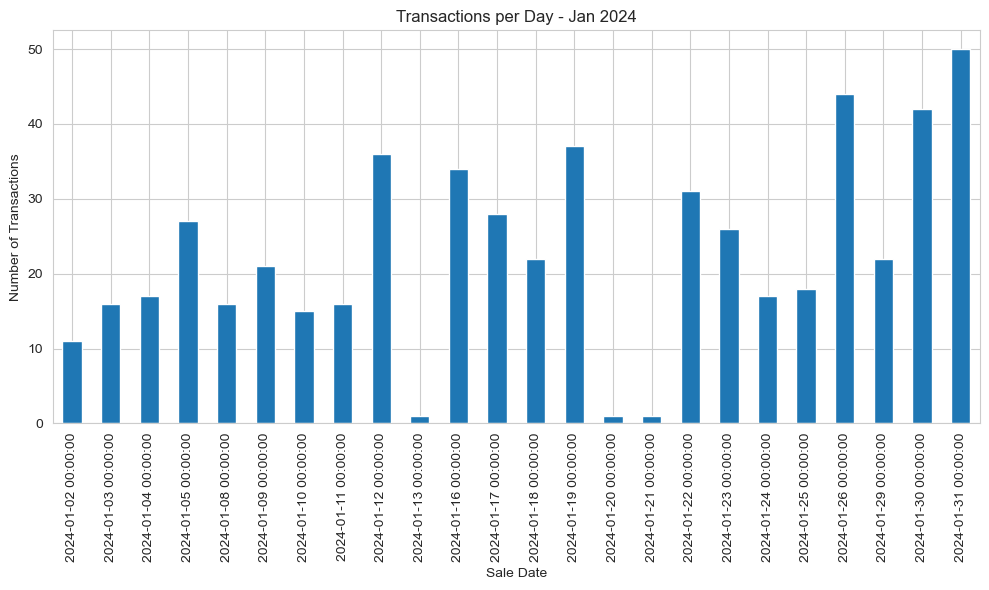

In [338]:
# unique values and count for sale_date
jan2024['sale_date'].value_counts().sort_index().plot(kind = 'bar')

plt.xlabel('Sale Date')
plt.ylabel('Number of Transactions')
plt.title('Transactions per Day - Jan 2024')

plt.tight_layout()
plt.show()

Increasing sales trend as the month comes to a close.
For the sake of building a better model, let's add a new column with the day of the week for each transaction.

In [344]:
# determine day of the week and add to new column
jan2024['day_of_week'] = jan2024['sale_date'].dt.day_name()

# check the first five rows
jan2024[['parcel_id', 'street_name', 'grantor', 'grantee', 'sale_date', 'is_institutional','day_of_week']].head()

,parcel_id,street_name,grantor,grantee,sale_date,is_institutional,day_of_week
1,17041600350,768 TIMBERLAND ST,CHAPMAN ERIC & CAPPARELLI TANIA,HABERSTROH BRADLEY & AMANDA,2024-01-31,0,Wednesday
2,20030200460,492 TEAGUE DR,ONLINE ABSTRACTING LLC,AJS AUCTIONS LLC,2024-01-08,1,Monday
9,16002600290,3005 TREESIDE TER,TOLL SOUTHEAST LP COMPANY INC,SINGH RAHUL & ARJITA,2024-01-11,1,Thursday
16,16023400160,1718 CHRISTIE DR,MENENDEZ INVESTORS LLC,MARYANSKI MICHAEL J & MELODY A,2024-01-26,1,Friday
17,17023800320,103 MELINDA WAY SE,GARCIA JOSE ERASMO JR &,SDO REALTY LLC,2024-01-09,0,Tuesday


**Column**: `sale_price`

In [350]:
jan2024['sale_price'].describe()

count       549.00
mean     501343.81
std      423993.67
min       15000.00
25%      324500.00
50%      422980.00
75%      548900.00
max     6674000.00
Name: sale_price, dtype: float64

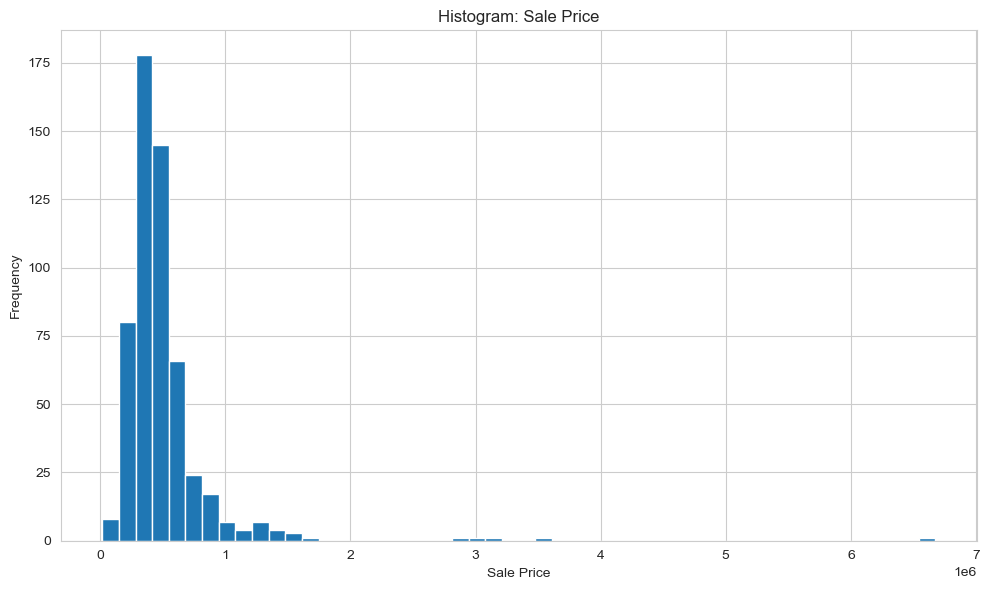

In [354]:
jan2024['sale_price'].plot(kind = 'hist', bins = 50)

plt.xlabel('Sale Price')
plt.ylabel('Frequency')
plt.title('Histogram: Sale Price')

plt.tight_layout()
plt.show()

Most sales are under 1M, let's close in on that.

In [375]:
# sales transacttions under 1M dollars
jan2024[jan2024['sale_price'] < 1000000]['sale_price'].describe()

count      521.00
mean    434279.54
std     168905.92
min      15000.00
25%     320000.00
50%     404000.00
75%     519001.00
max     995073.00
Name: sale_price, dtype: float64

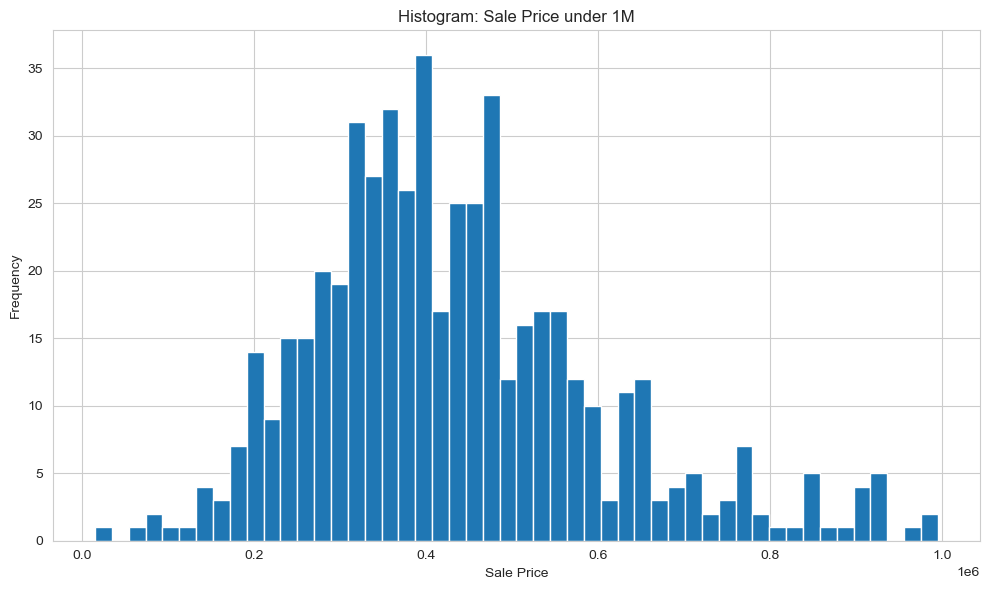

In [379]:
# plot new histogram for sales under 1M

jan2024[jan2024['sale_price'] < 1000000]['sale_price'].plot(kind = 'hist', bins = 50)
plt.xlabel('Sale Price')
plt.ylabel('Frequency')
plt.title('Histogram: Sale Price under 1M')
plt.tight_layout()
plt.show()

**Column**: `sales_validity`

There should just be one value.

In [388]:
# unique values and count for sales_validity
jan2024['sales_validity'].value_counts()

sales_validity
VALID SALE    549
Name: count, dtype: int64

**Column**: `acres`

In [394]:
jan2024['acres'].describe()

count   549.00
mean      0.17
std       0.51
min       0.00
25%       0.00
50%       0.00
75%       0.05
max       4.93
Name: acres, dtype: float64

**Comment on this later...**

In [397]:
jan2024[jan2024['acres'] == 0]['square_ft'].describe()

count    361.00
mean    1942.60
std      821.99
min        0.00
25%     1369.00
50%     1700.00
75%     2318.00
max     5998.00
Name: square_ft, dtype: float64

In [399]:
jan2024[jan2024['acres'] == 0]['sale_price'].describe()

count       361.00
mean     436216.16
std      213829.93
min       59900.00
25%      310000.00
50%      389120.00
75%      500000.00
max     1585000.00
Name: sale_price, dtype: float64

In [47]:
# unique values and count for acres
print(jan2024['acres'].nunique())
jan2024['acres'].value_counts()

122


acres
0.00    361
0.03     15
0.02      7
0.40      5
0.25      4
       ... 
0.34      1
0.39      1
0.69      1
0.37      1
0.14      1
Name: count, Length: 122, dtype: int64

In [48]:
# unique values and count for tax_district
print(jan2024['tax_district'].nunique())
jan2024['tax_district'].value_counts()

11


tax_district
(9) UNINCORPORATED                        311
(M) MABLETON                               65
(4) MARIETTA                               50
(6) SMYRNA                                 36
(3) KENNESAW                               27
(1) ACWORTH                                23
(5) POWDER SPRINGS                         22
(2) AUSTELL                                10
(6   A) SMYRNA TAD 1 ATL RD CORR(2004)      3
(9Y) COUNTY CSSD2                           1
(8) TCID                                    1
Name: count, dtype: int64

In [49]:
# unique values and count for square_ft
print(jan2024['square_ft'].nunique())
jan2024['square_ft'].value_counts()

466


square_ft
0       7
1125    4
1120    4
1248    4
1075    3
       ..
1956    1
2739    1
1218    1
810     1
1515    1
Name: count, Length: 466, dtype: int64

In [50]:
# unique values and count for neighborhood
print(jan2024['neighborhood'].nunique())
jan2024['neighborhood'].value_counts()

437


neighborhood
HOMESITE - M0009991                 8
HOLLOMAN RESERVE - 18044656         6
WILLOWCREST TOWNHOMES - M0009641    6
GARRISON PARC PH 2 - 16034654       5
AVENBROOK - M0004662                5
                                   ..
MC DANIEL FARM - 20023551           1
SHALLOWFORD TRACE - 16033387        1
PACES CLUB - 20033328               1
PARK PLACE TOWNHOMES - 01209530     1
DURHAM ESTATES - 16121176           1
Name: count, Length: 437, dtype: int64

In [51]:
# unique values and count for zoning
print(jan2024['zoning'].nunique())
jan2024['zoning'].value_counts()

21


zoning
R-20 - SINGLE FAM RES 20,000 SF             11
FST - FEE SIMPLE TOWNHOUSE RES               8
R-15/OSC - RES SING FAM/ OPEN SPACE          6
R-30 - SINGLE FAM RES 30,000 SF              5
R-20/R30 - SFR 20,000SF / SFR 30,000SF       5
LI - LIGHT INDUSTRIAL                        5
RM-8 - RES MULTI FAMILY                      4
OI - OFFICE IND                              3
R-15/WS - SNGL FAM RES 15,000 SF/ W STIP     3
MU - MIXED USE DEVELOPMENT                   3
UC - URBAN CONDO RES                         2
R-4 - SINGLE FAMILY RESIDENTIAL              2
NS - NEIGHBORHOOD SHOPPING                   2
GC - GENERAL COMMERCIAL                      2
CRC - COMMUNITY RETAIL COMMERCIAL            2
RSL - RES SENIOR FAM LIVING FACILITI         1
RM-12 - RES MULTI FAMILY                     1
R15                                          1
NRC - NBHD RETAIL COMMERCIAL                 1
HI - HEAVY INDUSTRIAL                        1
CS/WS - CONSERVATION SUBD/W STIPULATIO       1
Name: 

In [52]:
# unique values and count for districts
print(jan2024['districts'].nunique())
jan2024['districts'].value_counts()

6


districts
17    142
16    133
20    111
19    109
18     38
1      16
Name: count, dtype: int64

In [53]:
# unique values and count for landlots
print(jan2024['landlots'].nunique())
jan2024['landlots'].value_counts()

370


landlots
1216    6
1248    6
886     6
833     5
144     5
       ..
926     1
71      1
999     1
699     1
296     1
Name: count, Length: 370, dtype: int64

In [54]:
# unique values and count for foundation
print(jan2024['foundation'].nunique())
jan2024['foundation'].value_counts()

4


foundation
4 - FULL     206
1 - NONE     204
2 - CRAWL     81
3 - PART      38
Name: count, dtype: int64

In [55]:
# unique values and count for school_district
print(jan2024['school_district'].nunique())
jan2024['school_district'].value_counts()

17


school_district
Campbell High - 517        70
McEachern High - 501       49
North Cobb High - 505      46
South Cobb High - 503      45
Marietta High - 999        42
Wheeler High - 509         37
Pebblebrook High - 506     34
Sprayberry High - 510      30
Allatoona High - 521       24
Osborne High - 507         23
Lassiter High - 512        22
Kennesaw Mtn High - 518    22
Pope High - 515            21
Walton High - 511          20
Hillgrove High - 520       19
Kell High - 519            18
Harrison High - 516        15
Name: count, dtype: int64

---
**Review Columns: Contents, Stats, Format to Correct Data Type**

Turn this into a function to avoid DRY: pass in the column names directly from DF

In [57]:
# parcel_id has no nulls, convert to strings and confirm
jan2024['parcel_id'] = jan2024['parcel_id'].astype('string')
print(jan2024['parcel_id'].dtype)

string


In [58]:
# verify parcel IDs lengths
jan2024['parcel_id'].str.len().value_counts()

parcel_id
11    533
10     16
Name: count, dtype: Int64

In [59]:
# check leading characters for parcel IDs

In [60]:
jan2024['parcel_id'].str[0].value_counts().sort_index()

parcel_id
1    438
2    111
Name: count, dtype: Int64

In [61]:
# any leading white space in parcel IDs?
jan2024['parcel_id'].str.startswith(' ').sum()

0

In [62]:
# and in case there are any trailing white spaces, remove - then check lengths again for consistency
jan2024['parcel_id'].str.strip().str.len().value_counts()

parcel_id
11    533
10     16
Name: count, dtype: Int64

In [63]:
# take a look at parcel IDs with 10 characters - first five
jan2024[jan2024['parcel_id'].str.len() == 10]['parcel_id'].head(5)

50     1002800750
114    1010200440
280    1010100500
609    1005200100
734    1007101020
Name: parcel_id, dtype: string

In [64]:
# check the same rows
jan2024[jan2024['parcel_id'].str.len() == 10].head(5)

,parcel_id,street_name,owner_name,owner_address,grantor,grantee,sale_date,sale_price,sales_validity,acres,tax_district,square_ft,neighborhood,zoning,districts,landlots,foundation,school_district
50,1002800750,3444 COLEBROOK TRL NE,CREASY SHARON,CREASY SHARON | 3444 COLEBROOK TRL | ROSWELL ...,GALAXY CHILDERS LAND LLC,BEAM CONSTRUCTION COMPANY INC,2024-01-22,250000.00,VALID SALE,0.50,(9) UNINCORPORATED,3829,GLENCOVE PLACE - 16034667,R15,1,28,1 - NONE,Pope High - 515
114,1010200440,3116 DENTON PL,GRAHAM ALEX,GRAHAM ALEX | 3116 DENTON PL NE | ROSWELL GA ...,FITE ROBERT V & SUSAN S,REVOCABLE TRUST OF SHIN S CHANG AND SU H,2024-01-18,972500.00,VALID SALE,0.00,(9) UNINCORPORATED,3325,EDGEWATER COVE - 16033017,NaN,1,102,4 - FULL,Pope High - 515
280,1010100500,4861 LAUREL SPRING DR,LAUREL SPRING DRIVE LLC,LAUREL SPRING DRIVE LLC | 224 AFFIRMED CT | A...,GOLDSTROHM FAMILY IRREVOCABLE TRUST,CURTIN THOMAS & JOANNE,2024-01-29,485000.00,VALID SALE,0.00,(9) UNINCORPORATED,2314,MOUNTAIN CREEK - 16021310,NaN,1,101,4 - FULL,Pope High - 515
609,1005200100,4694 SHALLOWFORD RD,GNATIUK ANDRII & NATALIIA,GNATIUK ANDRII & NATALIIA | 4694 SHALLOWFORD ...,CALLAWAY MAXWELL & MCDONALD LAUREN,GNATIUK ANDRII & NATALIIA,2024-01-29,415000.00,VALID SALE,0.00,(9) UNINCORPORATED,1371,MOUNTAIN CREEK - 16021310,NaN,1,52,4 - FULL,Pope High - 515
734,1007101020,4671 WYNMEADE PARK,CASCONE MICHAEL J & SUSANNE,CASCONE MICHAEL J & SUSANNE | 4671 WYNMEADE P...,HIGGINS ROBERT & CAROLYN M,CASCONE MICHAEL J,2024-01-25,1375000.00,VALID SALE,0.00,(9) UNINCORPORATED,5227,WYNMEADE - 16063146,NaN,1,71,4 - FULL,Walton High - 511


Nothing odd about the parcel IDs.  Read about Cobb County's parcel ID formatting and conventions, IDs can be anywhere in lenght from 10 to 14.

In [66]:
# street_name also has no nulls, convert to strings and confirm
jan2024['street_name'] = jan2024['street_name'].astype('string')
print(jan2024['street_name'].dtype)

string


In [67]:
# view first 10 entries
jan2024['street_name'].head(10)

1             768 TIMBERLAND ST
2                 492 TEAGUE DR
9             3005 TREESIDE TER
16             1718 CHRISTIE DR
17           103 MELINDA WAY SE
21            2511 OAK QUARTERS
26    1303 VININGS FOREST LN 13
27          2575 POPE MANOR WAY
30             410 WARD FARM DR
37             3690 SOMERSET DR
Name: street_name, dtype: string

In [68]:
# view last 10 entries
jan2024['street_name'].tail(10)

1435                 905 WYNNES RIDGE CIR
1437                3421 JOHNSON FERRY RD
1438                      3899 DOE RUN DR
1446    4537 VININGS CENTRAL TRCE UNIT 88
1452                 4911 BRIARLEIGH CHSE
1454                    1595 DEWBERRY TRL
1456                     4155 RIDGE RD SE
1459                4619 GLORY MAPLE TRCE
1460                           99 LAKE ST
1461                      210 SUBURBAN DR
Name: street_name, dtype: string

In [69]:
# remove any possible leading/trailing spaces
jan2024['street_name'] = jan2024['street_name'].str.strip()

In [70]:
# sanity check address lengths to catch odd entries
jan2024['street_name'].str.len().describe()

count   549.00
mean     18.17
std       4.34
min      10.00
25%      15.00
50%      17.00
75%      20.00
max      36.00
Name: street_name, dtype: Float64

My own address is 24 characters long.  IQR shows lengths from 15 thru 20, those addresses should make sense, be correct - not incomplete.

In [72]:
# check addresses with 9 characters
jan2024[jan2024['street_name'].str.len() == 9]['street_name']

Series([], Name: street_name, dtype: string)

Numbers are missing.  Check how many addresses are between 9 and 15 characters long.

In [74]:
# view addresses under 15 characters
jan2024[jan2024['street_name'].str.len() < 15]['street_name']

2        492 TEAGUE DR
53      839 WAYLAND CT
61         3502 LEE CT
66      90 STEWART AVE
99      942 AZALEA CIR
             ...      
1362    500 STEPNEY CT
1367     235 MCCORD ST
1376     461 VILLA AVE
1396     2057 LENOA LN
1460        99 LAKE ST
Name: street_name, Length: 82, dtype: string

Nothing odd or out of the ordinary, just keep an eye out for any address where the property number may be missing.

In [76]:
# check addresses with 40 characters
jan2024[jan2024['street_name'].str.len() == 40]['street_name']

Series([], Name: street_name, dtype: string)

Looks good.  Move on to the next column.